In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn

1. Create a straight line dataset using the linear regression formula (weight * X + bias).

        Set weight=0.3 and bias=0.9 there should be at least 100 datapoints total.

        Split the data into 80% training, 20% testing.

        Plot the training and testing data so it becomes visual.

In [2]:
weight = 0.3
bias = 0.9

X = torch.arange(0,1,0.01).unsqueeze(dim = 1)
y = weight*X + bias

print(f"Number of X samples: {len(X)}")
print(f"Number of y samples: {len(y)}")
print(f"First 10 X & y samples:\nX: {X[:10]}\ny: {y[:10]}")

Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]])
y: tensor([[0.9000],
        [0.9030],
        [0.9060],
        [0.9090],
        [0.9120],
        [0.9150],
        [0.9180],
        [0.9210],
        [0.9240],
        [0.9270]])


In [ ]:
train_split = int(len(X)*0.8)
X_train = X[:train_split]           # store everything from 0th index till 8th index but not include 8th
y_train = y[:train_split]
X_test = X[train_split:]            # store everything from 8th index till last index but not include last
y_test = y[train_split:]

len(X_train),len(y_train),len(X_test),len(y_test)

(80, 80, 20, 20)

C:\Users\HP\AppData\Local\Temp\ipykernel_43852\3561939891.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop = {"size" : 14})


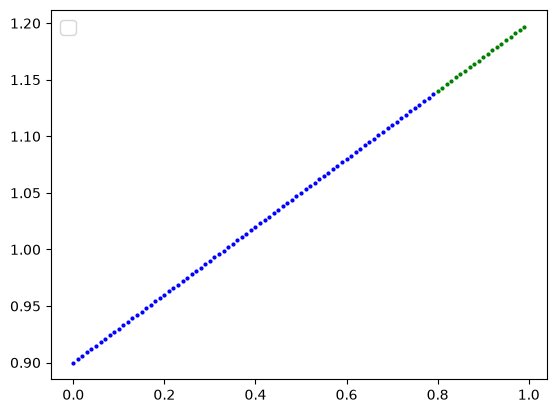

In [6]:
def plot_prediction(
        train_data = X_train,
        train_labels = y_train,
        test_data = X_test,
        test_labels = y_test,
        predictions = None
):
    plt.Figure(figsize=(10,7))
    plt.scatter(train_data,train_labels, color = 'b',s = 4,label = "Training data")
    plt.scatter(test_data,test_labels, color = 'g',s = 4,label = "Test data")

    if predictions is not None:
        plt.scatter(test_data,predictions,c = 'r',s = 4,label = "Predictions")
plt.legend(prop = {"size" : 14})
plot_prediction()

2. Build a PyTorch model by subclassing nn.Module.

        Inside should be a randomly initialized nn.Parameter() with requires_grad=True, one for weights and one for bias.

        Implement the forward() method to compute the linear regression function you used to create the dataset in 1.

        Once you've constructed the model, make an instance of it and check its state_dict().

        Note: If you'd like to use nn.Linear() instead of nn.Parameter() you can.

In [ ]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1) , requires_grad = True)           # capital P for parameters
        self.bias = nn.Parameter(torch.randn(1) , requires_grad = True)

    def forward(self,x):
        return self.weight*x + self.bias

torch.manual_seed(42)
model_1 = LinearRegressionModel()
model_1 , model_1.state_dict()

(LinearRegressionModel(),
 OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))]))

In [11]:
# ANOTHER WAY OF WRITING
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features = 1 , out_features = 1)

    def forward(self , x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

torch.manual_seed(42)
model_1 = LinearRegressionModel()
model_1 , model_1.state_dict()

(LinearRegressionModel(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [12]:
next(model_1.parameters()).device

device(type='cpu')

3. Create a loss function and optimizer using nn.L1Loss() and torch.optim.SGD(params, lr) respectively.

    Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2

    Write a training loop to perform the appropriate training steps for 300 epochs.
    
    The training loop should test the model on the test dataset every 20 epochs.

In [14]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.01)

In [15]:
# Training loop
# Train model for 300 epochs
torch.manual_seed(42)

epochs = 300

# Send data to target device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_1 = model_1.to(device)

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  ### Training

  # Put model in train mode
  model_1.train()

  # 1. Forward pass
  y_pred = model_1(X_train)

  # 2. Calculate loss
  loss = loss_fn(y_pred,y_train)

  # 3. Zero gradients
  optimizer.zero_grad()

  # 4. Backpropagation
  loss.backward()

  # 5. Step the optimizer
  optimizer.step()

  ### Perform testing every 20 epochs
  if epoch % 20 == 0:
    # Put model in evaluation mode and setup inference context 
    model_1.eval()
    with torch.inference_mode():
      # 1. Forward pass
      y_preds = model_1(X_test)
      # 2. Calculate test loss
      test_loss = loss_fn(y_preds,y_test)
      # Print out what's happening
      print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")

Epoch: 0 | Train loss: 0.128 | Test loss: 0.337
Epoch: 20 | Train loss: 0.082 | Test loss: 0.218
Epoch: 40 | Train loss: 0.072 | Test loss: 0.175
Epoch: 60 | Train loss: 0.065 | Test loss: 0.153
Epoch: 80 | Train loss: 0.058 | Test loss: 0.137
Epoch: 100 | Train loss: 0.051 | Test loss: 0.121
Epoch: 120 | Train loss: 0.045 | Test loss: 0.104
Epoch: 140 | Train loss: 0.038 | Test loss: 0.088
Epoch: 160 | Train loss: 0.031 | Test loss: 0.072
Epoch: 180 | Train loss: 0.024 | Test loss: 0.056
Epoch: 200 | Train loss: 0.017 | Test loss: 0.040
Epoch: 220 | Train loss: 0.010 | Test loss: 0.024
Epoch: 240 | Train loss: 0.003 | Test loss: 0.007
Epoch: 260 | Train loss: 0.008 | Test loss: 0.007
Epoch: 280 | Train loss: 0.008 | Test loss: 0.007


Make predictions with the trained model on the test data.

In [16]:
model_1.eval()

with torch.inference_mode():
    y_preds = model_1(X_test)
y_test

tensor([[1.1400],
        [1.1430],
        [1.1460],
        [1.1490],
        [1.1520],
        [1.1550],
        [1.1580],
        [1.1610],
        [1.1640],
        [1.1670],
        [1.1700],
        [1.1730],
        [1.1760],
        [1.1790],
        [1.1820],
        [1.1850],
        [1.1880],
        [1.1910],
        [1.1940],
        [1.1970]])

In [17]:
y_preds.cpu()

tensor([[1.1333],
        [1.1363],
        [1.1393],
        [1.1423],
        [1.1454],
        [1.1484],
        [1.1514],
        [1.1545],
        [1.1575],
        [1.1605],
        [1.1635],
        [1.1666],
        [1.1696],
        [1.1726],
        [1.1757],
        [1.1787],
        [1.1817],
        [1.1847],
        [1.1878],
        [1.1908]])

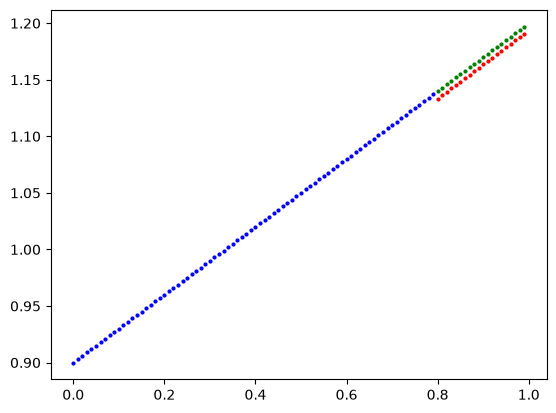

In [18]:
plot_prediction(predictions = y_preds.cpu())

In [ ]:
from pathlib import Path

# 1. Create models directory 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True , exist_ok = True)

# 2. Create model save path 
MODEL_NAME = "01_pytorch_model"

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(),f = MODEL_SAVE_PATH)

Saving model to models\01_pytorch_model


In [20]:
loaded_model = LinearRegressionModel()
loaded_model.load_state_dict(torch.load(f = MODEL_SAVE_PATH))
loaded_model.to(device)

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [21]:
y_preds_new = loaded_model(X_test)
y_preds == y_preds_new

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [22]:
loaded_model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.3028]])),
             ('linear_layer.bias', tensor([0.8910]))])